<a href="https://colab.research.google.com/github/krishnasmv/VisionLanguageModel-VLM/blob/main/Embeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
# Import necessary libraries

from transformers import CLIPTokenizer # Tokenizer for the CLIP model, converts text into tokens
from transformers import CLIPProcessor # Preprocessor for CLIP model, handles image/text preprocessing
from transformers import CLIPModel     # CLIP model for image-text embedding and similarity tasks

import torch                           # PyTorch library, used for tensor operations and GPU computations
import torch.nn.functional as F        # Contains functional API for neural network operations (e.g., activations, loss functions)
import numpy as np                     # Numerical library for array manipulation and computations

import matplotlib.pyplot as plt        # Library for plotting images and visualizations
import seaborn as sns                  # Library for creating statistical visualizations

from PIL import Image                  # Used for loading and processing images
import requests                        # Used to fetch images from URLs
from io import BytesIO                 # Enables reading binary data as file-like objects in memory

Load Model

In [26]:

# Define the model name for the CLIP variant (Vision Transformer - base, 32x32 patches)
model_name = "openai/clip-vit-base-patch32"

# Load the pre-trained CLIP model from Hugging Face
model = CLIPModel.from_pretrained(model_name)

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [27]:
# Load the tokenizer associated with the specified CLIP model
tokenizer = CLIPTokenizer.from_pretrained(model_name)


# Define a list of text descriptions to embed
text = ["a donut", "a cookie", "an airplane", "a cat"]

# Tokenize and preprocess the text inputs with padding to ensure equal sequence lengths
inputs = tokenizer(text, padding=True, return_tensors="pt")

# Unpack the inputs
input_ids = inputs.input_ids  # Tokenized and encoded text input IDs

# Print information about the unpacked inputs
print("Input IDs (shape):", input_ids.shape)
print(input_ids)

Input IDs (shape): torch.Size([4, 4])
tensor([[49406,   320, 18471, 49407],
        [49406,   320,  9367, 49407],
        [49406,   550, 16451, 49407],
        [49406,   320,  2368, 49407]])


In [28]:
# Compute text embeddings without tracking gradients (inference mode)
with torch.no_grad():
    # Obtain text embeddings (feature vectors) from the CLIP model
    # The get_text_features method returns a BaseModelOutputWithPooling object
    # from which the actual embeddings can be extracted using .pooler_output
    text_embeddings_output = model.get_text_features(**inputs)
    text_embeddings = text_embeddings_output.pooler_output

# Print the shape of the resulting text embeddings tensor
# The shape is [number_of_texts, embedding_dimension]
print(text_embeddings.shape)

torch.Size([4, 512])


Calculate Cosine Similarity

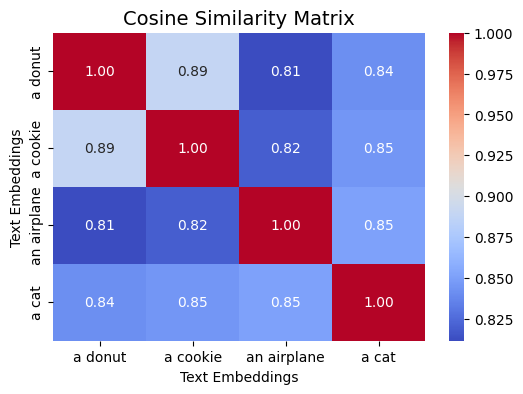

In [29]:
# Assuming text_embeddings is a tensor of shape [n, d], where:
# - n = number of text prompts
# - d = embedding dimension

# Compute the n x n cosine similarity matrix between all pairs of embeddings
# text_embeddings[:, None, :] reshapes embeddings to [n, 1, d]
# text_embeddings[None, :, :] reshapes embeddings to [1, n, d]
# cosine_similarity calculates similarity along the last dimension (d)
cosine_similarity = F.cosine_similarity(
    text_embeddings[:, None, :],    # Shape: [n, 1, d]
    text_embeddings[None, :, :],    # Shape: [1, n, d]
    dim=2                           # Calculate similarity along embedding dimension d
).cpu().numpy()                     # Move to CPU and convert tensor to NumPy array for plotting

# Initialize a matplotlib figure with specified size (width=6, height=4)
plt.figure(figsize=(6, 4))

# Create a heatmap visualization using seaborn to display the cosine similarity matrix
sns.heatmap(
    cosine_similarity,              # Matrix to visualize (n x n similarity scores)
    annot=True,                     # Annotate each cell with numeric similarity value
    fmt=".2f",                      # Format annotations to two decimal places
    cmap="coolwarm",                # Colormap for heatmap indicating negative/positive similarities
    xticklabels=text,               # Label x-axis with the original text prompts
    yticklabels=text                # Label y-axis with the original text prompts
)

# Set the plot title with font size 14
plt.title("Cosine Similarity Matrix", fontsize=14)

# Label x-axis as "Text Embeddings"
plt.xlabel("Text Embeddings")

# Label y-axis as "Text Embeddings"
plt.ylabel("Text Embeddings")

# Display the plot
plt.show()

In [30]:
# Utility function for displaying images with labels
def plot_images(images, labels):
  n = len(images)                        # Number of images loaded successfully
  fig, axes = plt.subplots(1, n)         # Create subplots with one row and n columns
  # Loop through each subplot axis, image, and its label to display them
  for ax, img, lbl in zip(axes, images, labels):
      ax.imshow(img)                     # Display the image on the axis
      ax.set_title(lbl)                  # Set the title of the subplot to the image label
      ax.axis("off")                     # Turn off axis ticks and labels for clarity

  plt.tight_layout()                     # Adjust layout to prevent overlap
  plt.show()

Load and Display Images

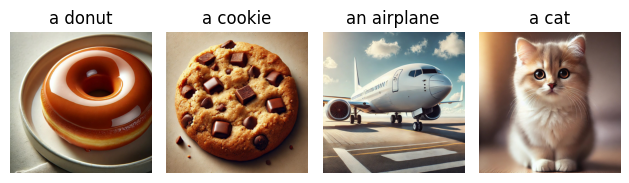

In [31]:
# Load a pre-trained CLIP processor for handling images and text preprocessing
processor = CLIPProcessor.from_pretrained(model_name)
# Dictionary containing labels and their corresponding image URLs
image_urls = {
    "a donut": "https://learnopencv.com/wp-content/uploads/2025/03/donut.jpeg",
    "a cookie": "https://learnopencv.com/wp-content/uploads/2025/03/cookie.jpeg",
    "an airplane": "https://learnopencv.com/wp-content/uploads/2025/03/airplane.jpeg",
    "a cat": "https://learnopencv.com/wp-content/uploads/2025/03/cat.jpeg"
}

# Extract the list of labels from the dictionary keys
labels = list(image_urls.keys())

# Define a robust function to load images from URLs
def load_image(url):
    headers = {'User-Agent': 'Mozilla/5.0'}        # Set headers to avoid blocking by web servers
    response = requests.get(url, headers=headers)  # Request the image from the URL
    response.raise_for_status()                    # Raise an error if the download fails
    # Open the downloaded image, convert it to RGB format, and return the PIL Image
    return Image.open(BytesIO(response.content)).convert("RGB")

# Initialize empty lists for successfully loaded images and their labels
images = []

# Loop through each label to load the associated image
for label in labels:
    try:
        img = load_image(image_urls[label])  # Load image from URL
        images.append(img)                   # Append loaded image to images list
    except requests.exceptions.RequestException as e:
        # If an image fails to load, print an error message
        print(f"Failed to load {label}: {e}")

# Display the loaded images in a single row using matplotlib
plot_images(images, labels)

Calculate Image Emdeddings & Display Similarity

torch.Size([4, 512])


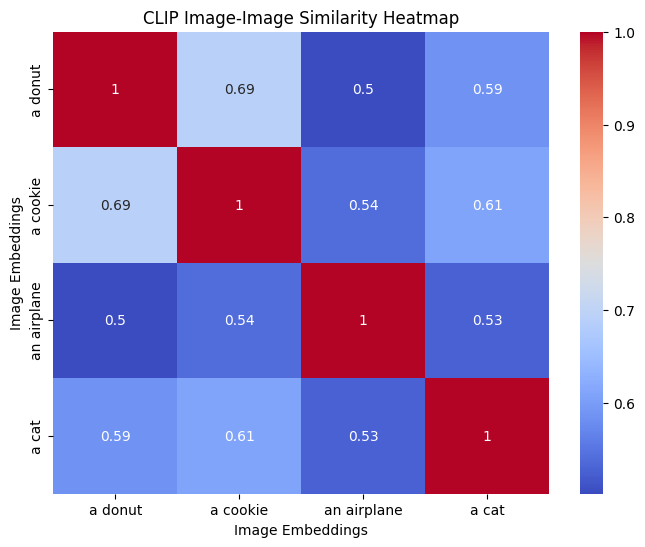

In [32]:
# Preprocess images using CLIP processor to prepare for embedding generation
image_inputs = processor(images=images, return_tensors="pt")

with torch.no_grad():
  # Generate image embeddings using the CLIP model
  image_embeddings = model.get_image_features(**image_inputs)

# Print the shape of the resulting image embeddings tensor
# The shape is [number_of_images, embedding_dimension]
print(image_embeddings.pooler_output.shape)

# Compute similarity matrix
img_similarity = F.cosine_similarity(image_embeddings.pooler_output[:, None, :], image_embeddings.pooler_output[None, :, :], dim=2).cpu().numpy()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(img_similarity, annot=True, xticklabels=labels, yticklabels=labels, cmap="coolwarm")
plt.xlabel("Image Embeddings")
plt.ylabel("Image Embeddings")
plt.title("CLIP Image-Image Similarity Heatmap")
plt.show()

Calculate Image-Text Similarity

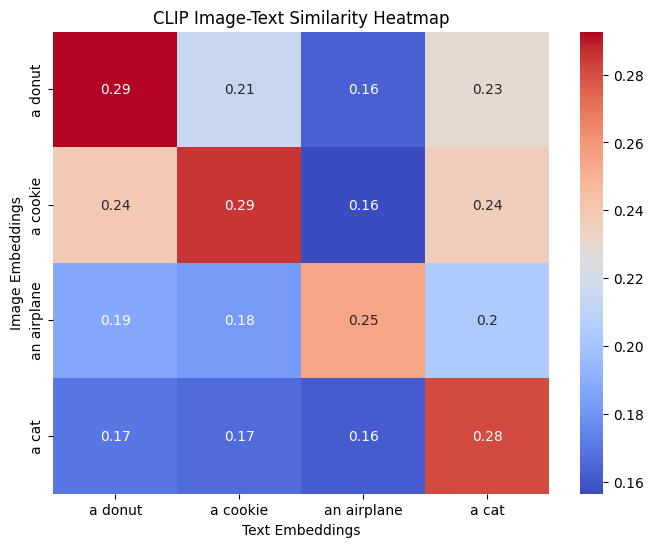

In [33]:
# Compute similarity matrix
txt_image_similarity = F.cosine_similarity(text_embeddings_output.pooler_output[:, None, :], image_embeddings.pooler_output[None, :, :], dim=2).cpu().numpy()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(txt_image_similarity, annot=True, xticklabels=labels, yticklabels=labels, cmap="coolwarm")
plt.xlabel("Text Embeddings")
plt.ylabel("Image Embeddings")
plt.title("CLIP Image-Text Similarity Heatmap")
plt.show()